<a href="https://colab.research.google.com/github/Rohan-nn/ML/blob/main/Spam_Detection_DecisionTree.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Spam Email Detection using Decision Tree

This project aims to classify SMS messages into spam or non-spam using Machine Learning.
The Decision Tree algorithm is used for classification.

In [ ]:
import pandas as pd
import numpy as np
import re
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report

In [ ]:
url = "https://raw.githubusercontent.com/justmarkham/pycon-2016-tutorial/master/data/sms.tsv"
df = pd.read_csv(url, sep='\t', header=None, names=['label','message'])

df.head()

,label,message
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."


In [ ]:
print("Dataset Shape:", df.shape)
df.info()

Dataset Shape: (5572, 2)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5572 entries, 0 to 5571
Data columns (total 2 columns):
 #   Column   Non-Null Count  Dtype 
---  ------   --------------  ----- 
 0   label    5572 non-null   object
 1   message  5572 non-null   object
dtypes: object(2)
memory usage: 87.2+ KB


In [ ]:
df['label'].value_counts()

,count
label,
ham,4825
spam,747


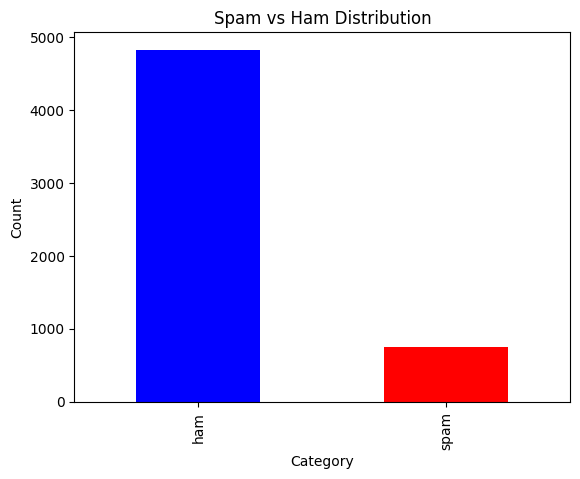

In [ ]:
df['label'].value_counts().plot(kind='bar', color=['blue','red'])
plt.title("Spam vs Ham Distribution")
plt.xlabel("Category")
plt.ylabel("Count")
plt.show()

In [ ]:
df['label'] = df['label'].map({'ham':0, 'spam':1})

def clean_text(text):
    text = text.lower()
    text = re.sub(r'\W', ' ', text)
    text = re.sub(r'\s+', ' ', text)
    return text

df['clean_message'] = df['message'].apply(clean_text)

df.head()

,label,message,clean_message
0,0,"Go until jurong point, crazy.. Available only ...",go until jurong point crazy available only in ...
1,0,Ok lar... Joking wif u oni...,ok lar joking wif u oni
2,1,Free entry in 2 a wkly comp to win FA Cup fina...,free entry in 2 a wkly comp to win fa cup fina...
3,0,U dun say so early hor... U c already then say...,u dun say so early hor u c already then say
4,0,"Nah I don't think he goes to usf, he lives aro...",nah i don t think he goes to usf he lives arou...


In [ ]:
vectorizer = TfidfVectorizer(stop_words='english', ngram_range=(1,2))

X = vectorizer.fit_transform(df['clean_message'])
y = df['label']

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print("Train Size:", X_train.shape)
print("Test Size:", X_test.shape)

Train Size: (4457, 37364)
Test Size: (1115, 37364)


In [ ]:
dt = DecisionTreeClassifier(random_state=42)
dt.fit(X_train, y_train)

DecisionTreeClassifier(random_state=42)

In [ ]:
y_pred = dt.predict(X_test)

In [ ]:
print("Accuracy :", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall   :", recall_score(y_test, y_pred))
print("F1 Score :", f1_score(y_test, y_pred))

Accuracy : 0.9668161434977578
Precision: 0.9057971014492754
Recall   : 0.8389261744966443
F1 Score : 0.8710801393728222


In [ ]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.98      0.99      0.98       966
           1       0.91      0.84      0.87       149

    accuracy                           0.97      1115
   macro avg       0.94      0.91      0.93      1115
weighted avg       0.97      0.97      0.97      1115



In [ ]:
params = {
    'max_depth': [5, 10, 20],
    'min_samples_split': [2, 5, 10]
}

grid = GridSearchCV(DecisionTreeClassifier(), params, cv=3)
grid.fit(X_train, y_train)

print("Best Parameters:", grid.best_params_)

Best Parameters: {'max_depth': 20, 'min_samples_split': 2}


In [ ]:
best_dt = grid.best_estimator_
y_pred_best = best_dt.predict(X_test)

In [ ]:
print("Final Accuracy :", accuracy_score(y_test, y_pred_best))
print("Final Precision:", precision_score(y_test, y_pred_best))
print("Final Recall   :", recall_score(y_test, y_pred_best))
print("Final F1 Score :", f1_score(y_test, y_pred_best))

Final Accuracy : 0.9641255605381166
Final Precision: 0.9097744360902256
Final Recall   : 0.8120805369127517
Final F1 Score : 0.8581560283687943


In [ ]:
sample = ["Congratulations! You have won a free lottery ticket"]
sample_clean = [clean_text(sample[0])]

sample_vec = vectorizer.transform(sample_clean)
prediction = best_dt.predict(sample_vec)

print("Message:", sample[0])
print("Prediction:", "Spam" if prediction[0] == 1 else "Not Spam")

Message: Congratulations! You have won a free lottery ticket
Prediction: Not Spam


## Conclusion

The Decision Tree model was successfully used to classify spam messages.
Hyperparameter tuning improved the performance of the model.
The system can be extended for real-time spam detection applications.
